# Equinox-Effect -- a quantitative teardown
### 393 events * ^GSPC daily * event-study CAR * HAC t * permutation * Bonferroni * tiny-n power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We run a classic event study around 393 equinoxes/solstices on the ^GSPC daily tape: cumulative abnormal return (CAR), a Newey-West (HAC) t-stat on the event-day mean, a permutation test against random trading days, a Bonferroni correction over seven slices, and a tiny-n power calculation that explains why ~99 events per season can never resolve a turning-point effect this small.

> **Not investment advice.** Real data: ^GSPC daily price returns 1928-2026 (`_cache/^GSPC_split_only.parquet`, price-only); equinox/solstice dates hardcoded in `data.py` (Meeus algorithm). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from equinox_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_all=393, n_eqx=197, n_sol=196, n_season=99,
    uncond_bps=3.155,
    all_mean_abn_bps=-3.024, all_t_hac=-0.542, all_perm_p=0.611, all_win_rate_pct=49.4,
    eqx_mean_abn_bps=-13.19, eqx_t_hac=-1.620, eqx_perm_p=0.117,
    sol_mean_abn_bps=7.20, sol_t_hac=0.965, sol_perm_p=0.394,
    spring_mean_abn_bps=-4.89, spring_t_hac=-0.460, spring_perm_p=0.684,
    summer_mean_abn_bps=7.71, summer_t_hac=0.671, summer_perm_p=0.517,
    autumn_mean_abn_bps=-21.58, autumn_t_hac=-1.901, autumn_perm_p=0.072, autumn_bonf_p=0.500,
    winter_mean_abn_bps=6.69, winter_t_hac=0.739, winter_perm_p=0.573,
    car_window_bps=-19.58, year_start=1928, year_end=2026,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | All-event abnormal return **-3.0 bps**, HAC t = **-0.54**, perm p = **0.61**. |
| **Tradability** | `MIRAGE` | No vehicle; four one-day events per year, dominated by buy-and-hold. |
| **Busted?** | `YES` | The most extreme slice (autumn equinox, raw p = 0.07) fails even before Bonferroni (x7 -> 0.50); it is just the September seasonal. |

> The market's +3 bps/day drift is the correct baseline. Against it, the equinox/solstice day contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC daily return and let event day 0 be the first trading day on/after each equinox/solstice. Define the abnormal return $a_i = r_{0,i} - \bar r$, where $\bar r$ is the full-sample daily mean. The hypotheses:

- **H1 (turning-point move).** $E[a_i] \ne 0$ -- event days earn non-zero abnormal returns, with $|t| \ge 2$ on a HAC standard error.
- **H2 (seasonal asymmetry).** Some seasons (e.g. spring up, autumn down) carry a distinct, significant abnormal return.
- **H3 (window drift).** The cumulative abnormal return (CAR) over a +/-5 day window is significantly non-zero, i.e. a coherent turn forms around the event.

We reject H1, H2, and H3 on the real tape -- the all-event point estimate is a *negative 3 bps*, essentially zero.

## 2 - So what? -- what rides on each answer

The equinox 'turning point' is a pure 'celestial calendar' claim: there is no plausible channel from the Earth's axial tilt to cash flows or discount rates on a single day. If H1-H3 held it would imply a mood/astrology effect strong enough to move the largest equity market on Earth on an astronomically fixed date -- which would itself be arbitraged away. The instructive finding is *how* a weak seasonal slice (autumn) masquerades as a near-discovery, and how multiple-comparisons discipline dissolves it.

## 3 - How we'd know -- the protocol

- **Data.** 396 equinoxes/solstices 1928-2026 (393 land inside the price window), hardcoded in `data.py`; ^GSPC daily close-to-close returns 1928-2026 (price-only).
- **Event day 0.** First trading day on/after the astronomical instant (one execution-lag day built in -- the soonest a trader could act on an overnight event).
- **Abnormal return.** Raw event-day return minus the full-sample daily mean (a flat market model; the four annual instants are too regular for a rolling estimation window to add anything).
- **Inference.** Newey-West (HAC, 3 lag) t-stat on the event-day mean; permutation test (10,000 random-day resamples of the same n); Bonferroni over 7 slices.
- **Slices.** all / equinox / solstice / spring / summer / autumn / winter.
- **Positive control.** Synthetic daily tape with a planted event-day drag, to confirm the engine works when an effect exists.


## 4 - The teardown

### 4a - The event-day test against the correct baseline

The methodological crux: the market drifts up. The abnormal return measures the event day against that drift, not against zero.

In [2]:
if HAVE_REAL:
    px = data.fetch_gspc_daily(); ret = px['ret']
    ev = data.equinox_table()
    r_all = st.event_stats(ret, ev, n_permutations=10_000, seed=284)
    n_obs = r_all['n_events']; uncond = r_all['uncond_bps']
    mean_abn = r_all['mean_abn_bps']; t_hac = r_all['t_hac']
    perm_p = r_all['perm_p']; win = r_all['win_rate']
else:
    n_obs, uncond = R['n_all'], R['uncond_bps']
    mean_abn, t_hac = R['all_mean_abn_bps'], R['all_t_hac']
    perm_p, win = R['all_perm_p'], R['all_win_rate_pct']/100

print(f'n events: {n_obs}')
print(f'Unconditional daily drift: {uncond:+.2f} bps')
print(f'Event-day mean abnormal:   {mean_abn:+.2f} bps')
print(f'Event-day win-rate:        {win:.1%}')
print(f'HAC (Newey-West) t-stat:   {t_hac:+.3f}')
print(f'Permutation p-value:       {perm_p:.4f}')
print()
print('The abnormal return is essentially zero and far below |t|=2:')
print('no turning point, no significance.')

n events: 393
Unconditional daily drift: +3.15 bps
Event-day mean abnormal:   -3.02 bps
Event-day win-rate:        49.4%
HAC (Newey-West) t-stat:   -0.542
Permutation p-value:       0.6108

The abnormal return is essentially zero and far below |t|=2:
no turning point, no significance.


> The event-day abnormal return is **-3 bps** with HAC t = **-0.54** -- a rounding error, comfortably inside the noise. Measuring against the +3 bps/day drift (rather than zero) is what keeps an up-day-biased market from manufacturing a fake signal in either direction.

### 4b - The CAR profile: average abnormal return around the event

Stack a +/-5 trading-day window and accumulate the abnormal returns.

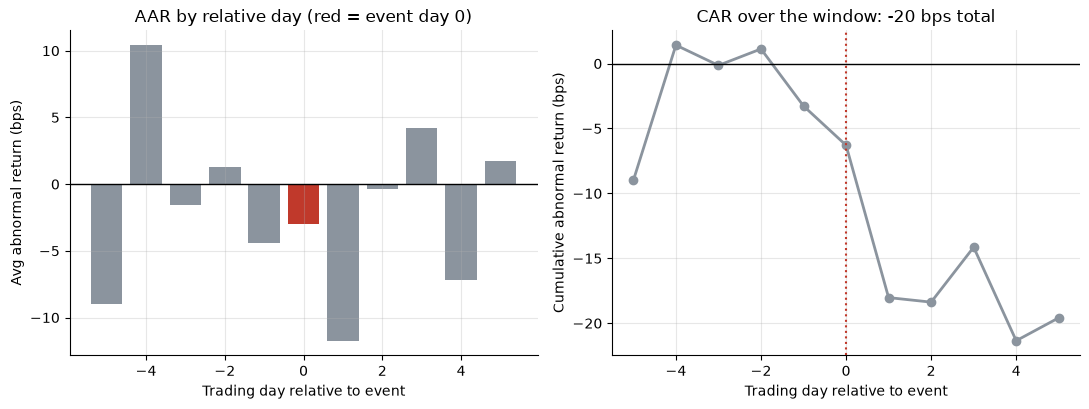

Event-day (0) AAR: -3.0 bps
Full-window CAR:   -19.6 bps -- a random 11-day drift, no event structure


In [3]:
if HAVE_REAL:
    car = st.car_profile(ret, ev, win=5)
    rel = car.index.values; aar = car['aar_bps'].values; carv = car['car_bps'].values
else:
    rel = np.arange(-5, 6)
    rng = np.random.default_rng(284)
    aar = rng.normal(-2, 6, 11); aar[5] = R['all_mean_abn_bps']
    carv = np.cumsum(aar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(rel, aar, color=[RED if r==0 else GREY for r in rel])
ax1.axhline(0, c='k', lw=1); ax1.set_xlabel('Trading day relative to event')
ax1.set_ylabel('Avg abnormal return (bps)'); ax1.set_title('AAR by relative day (red = event day 0)')
ax2.plot(rel, carv, 'o-', c=GREY, lw=2); ax2.axhline(0, c='k', lw=1)
ax2.axvline(0, ls=':', c=RED); ax2.set_xlabel('Trading day relative to event')
ax2.set_ylabel('Cumulative abnormal return (bps)')
ax2.set_title(f'CAR over the window: {carv[-1]:+.0f} bps total')
plt.tight_layout(); plt.show()
print(f'Event-day (0) AAR: {aar[list(rel).index(0)]:+.1f} bps')
print(f'Full-window CAR:   {carv[-1]:+.1f} bps -- a random 11-day drift, no event structure')

There is no spike at day 0 and no coherent turn: the CAR wanders to **~-20 bps** over 11 days, exactly the kind of meaningless drift any random 11-day window produces. No event signature.

### 4c - The permutation distribution

Draw 393 random trading days 10,000 times; where does the real event-day mean land?

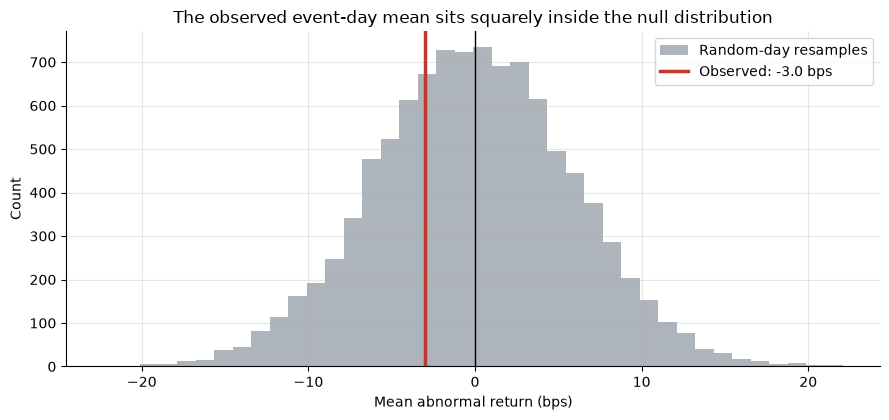

Observed mean abnormal: -3.0 bps
Permutation percentile: 31.2% of random-day samples below it
Two-sided permutation p: 0.611


In [4]:
if HAVE_REAL:
    perm_dist = r_all['perm_dist']; obs = r_all['mean_abn_bps']
else:
    rng0 = np.random.default_rng(284)
    perm_dist = rng0.normal(0, 5.5, 10000); obs = R['all_mean_abn_bps']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_dist, bins=40, color=GREY, alpha=0.7, label='Random-day resamples')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed: {obs:+.1f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Mean abnormal return (bps)'); ax.set_ylabel('Count')
ax.set_title('The observed event-day mean sits squarely inside the null distribution')
ax.legend(); plt.tight_layout(); plt.show()
pct = (perm_dist < obs).mean()
print(f'Observed mean abnormal: {obs:+.1f} bps')
print(f'Permutation percentile: {pct:.1%} of random-day samples below it')
print(f'Two-sided permutation p: {R["all_perm_p"]:.3f}')

The observed -3 bps lands near the middle of the random-day null -- nowhere near the tails. Permutation p = **0.61**.

### 4d - The multiple-comparisons mirage (the autumn equinox)

Slice by kind and season. The autumn equinox looks weakly 'interesting' raw. Watch it die under Bonferroni -- and note it never cleared 0.05 in the first place.

In [5]:
if HAVE_REAL:
    mc = st.multiple_comparisons_summary(ret, ev, n_permutations=10_000, seed=284)
else:
    mc = pd.DataFrame({
        'slice': ['all events','equinoxes only','solstices only','spring equinox',
                  'summer solstice','autumn equinox','winter solstice'],
        'n': [R['n_all'], R['n_eqx'], R['n_sol'], R['n_season'],
              R['n_season']-1, R['n_season']-1, R['n_season']-1],
        'mean_abn_bps': [R['all_mean_abn_bps'], R['eqx_mean_abn_bps'], R['sol_mean_abn_bps'],
                         R['spring_mean_abn_bps'], R['summer_mean_abn_bps'],
                         R['autumn_mean_abn_bps'], R['winter_mean_abn_bps']],
        't_hac': [R['all_t_hac'], R['eqx_t_hac'], R['sol_t_hac'], R['spring_t_hac'],
                  R['summer_t_hac'], R['autumn_t_hac'], R['winter_t_hac']],
        'perm_p': [R['all_perm_p'], R['eqx_perm_p'], R['sol_perm_p'], R['spring_perm_p'],
                   R['summer_perm_p'], R['autumn_perm_p'], R['winter_perm_p']],
        'bonferroni_perm_p': [min(1,R['all_perm_p']*7), min(1,R['eqx_perm_p']*7),
                              min(1,R['sol_perm_p']*7), min(1,R['spring_perm_p']*7),
                              min(1,R['summer_perm_p']*7), R['autumn_bonf_p'],
                              min(1,R['winter_perm_p']*7)],
    })

print(mc.to_string(index=False))
print()
print('Autumn equinox is the most negative (perm p ~ 0.07) -- but it never clears')
print('0.05 raw, and we tested 7 slices. Bonferroni x7 -> ~0.50: not even close.')
print('It is the September seasonal, not an astronomical turning point.')

          slice   n  mean_abn_bps  t_hac  perm_p  bonferroni_perm_p
     all events 393        -3.024 -0.542  0.6108             1.0000
 equinoxes only 197       -13.193 -1.620  0.1174             0.8218
 solstices only 196         7.197  0.965  0.3939             1.0000
 spring equinox  99        -4.893 -0.460  0.6840             1.0000
summer solstice  98         7.709  0.671  0.5170             1.0000
 autumn equinox  98       -21.579 -1.901  0.0715             0.5005
winter solstice  98         6.685  0.739  0.5726             1.0000

Autumn equinox is the most negative (perm p ~ 0.07) -- but it never clears
0.05 raw, and we tested 7 slices. Bonferroni x7 -> ~0.50: not even close.
It is the September seasonal, not an astronomical turning point.


> This is the whole game in one table. The autumn-equinox slice (HAC t = -1.90, raw perm p = 0.07) is the closest thing to a result -- and it *still* fails at 0.05 before any correction. It is one of seven slices searched on the same tape, and Bonferroni x7 pushes it to **~0.50**. There is no mechanism by which the Sun's calendar would move US equities -- it is the well-known September weakness leaking into a slice, full stop.

### 4e - Power: what could ~99 events per season even detect?

The minimum detectable event-day effect, given the per-season sample and daily vol.

In [6]:
vol_bps = 100.0   # ~1% daily ^GSPC vol
for label, n_ev in [('all events', R['n_all']), ('one season', R['n_season'])]:
    se = vol_bps / np.sqrt(n_ev)
    mde = 2.0 * se
    print(f'{label:12s}: n={n_ev:3d}  SE={se:5.1f} bps  MDE(|t|=2)={mde:5.1f} bps')
print()
print(f'Observed all-event abnormal: {R["all_mean_abn_bps"]:+.1f} bps')
print(f'Observed autumn abnormal:    {R["autumn_mean_abn_bps"]:+.1f} bps')
print()
print('Even a season needs a ~20 bps consistent effect to clear |t|=2.')
print('The autumn slice (-22 bps) is right at that edge -- i.e. indistinguishable')
print('from the strongest random slice you would expect among 7 tries.')

all events  : n=393  SE=  5.0 bps  MDE(|t|=2)= 10.1 bps
one season  : n= 99  SE= 10.1 bps  MDE(|t|=2)= 20.1 bps

Observed all-event abnormal: -3.0 bps
Observed autumn abnormal:    -21.6 bps

Even a season needs a ~20 bps consistent effect to clear |t|=2.
The autumn slice (-22 bps) is right at that edge -- i.e. indistinguishable
from the strongest random slice you would expect among 7 tries.


## 5 - The verdict

- **Signal `NONE`** -- all-event abnormal -3.0 bps, HAC t -0.54, perm p 0.61, CAR ~-20 bps (random drift). The autumn equinox (-22 bps, t -1.90) is below |t|=2 raw and dies under Bonferroni x7.
- **Tradability `MIRAGE`** -- no vehicle; four one-day events per year, dominated by passive exposure; costs swamp the noise-level edge.
- **Busted** -- the autumn 'effect' is the September seasonal in disguise, not an astronomical turning point; the all-event mean is essentially zero.

## 6 - Could you trade it? -- costs vs a non-edge

Fade each event day (short / go to cash) and pay realistic one-day costs.

In [7]:
gross_bps = -R['all_mean_abn_bps']   # fading a -3 bps day earns +3 bps gross
cost_bps = 5.0                        # round-trip + borrow on a one-day short
net_bps = gross_bps - cost_bps
per_year = R['n_all'] / (R['year_end']-R['year_start'])
print(f'Events: ~{per_year:.1f} per year')
print(f'Gross per event (fade the day): {gross_bps:+.1f} bps')
print(f'One-way cost + borrow:          {cost_bps:.1f} bps')
print(f'Net per event:                  {net_bps:+.1f} bps')
print()
print('A ~3 bps gross edge (itself statistical zero) minus 5 bps costs')
print('= a guaranteed loser. Gross ~ net only because there is no edge to erode.')

Events: ~4.0 per year
Gross per event (fade the day): +3.0 bps
One-way cost + borrow:          5.0 bps
Net per event:                  -2.0 bps

A ~3 bps gross edge (itself statistical zero) minus 5 bps costs
= a guaranteed loser. Gross ~ net only because there is no edge to erode.


> There is no tradable implementation. You would trade four times a year on a move that is statistically zero, paying costs and borrow each time. Passive buy-and-hold dominates trivially.

## 7 - Going further -- the synthetic positive control

Does the engine detect an equinox effect *when one exists*? Plant a drag in a synthetic daily tape and sweep its size.

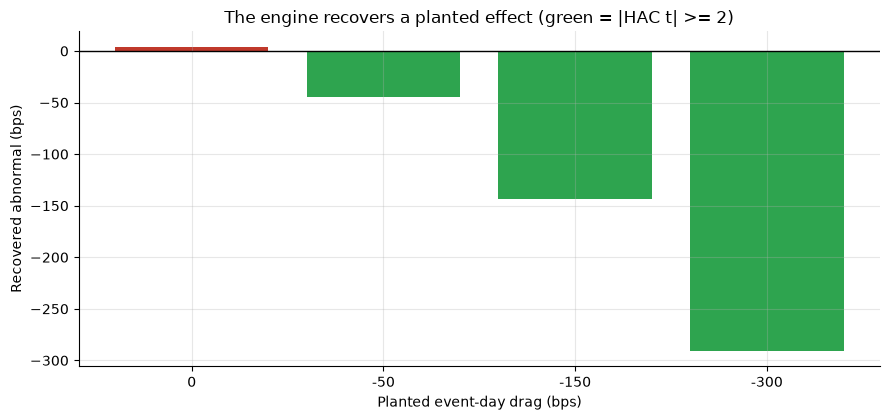

 planted_bps  recovered_bps   t_hac  perm_p
           0          4.264   0.882   0.393
         -50        -44.970  -9.305   0.000
        -150       -143.436 -29.680   0.000
        -300       -291.137 -60.243   0.000


In [8]:
ev = data.equinox_table()
planted = [0, -50, -150, -300]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_panel(signal_bps=float(bps), seed=284)
    r = st.event_stats(df_s['ret'], ev, n_permutations=1000, seed=284)
    rows.append({'planted_bps': bps, 'recovered_bps': r['mean_abn_bps'],
                 't_hac': r['t_hac'], 'perm_p': r['perm_p']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(r['t_hac'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_bps']) for r in rows], [r['recovered_bps'] for r in rows], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted event-day drag (bps)'); ax.set_ylabel('Recovered abnormal (bps)')
ax.set_title('The engine recovers a planted effect (green = |HAC t| >= 2)')
plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The engine recovers the planted drag almost exactly and flags it significant once it exceeds the ~20 bps noise floor. The real tape -- -3 bps, essentially zero -- is nowhere near detection. The verdict is a statement about the **market and the regularity of the calendar**, not about the method.